# 04 - Report

Collects every run that has been trained and evaluated into a single comparison table and set of figures

In [1]:
#----------------------------------------------------------------------------------------<Make the package importable>---||
import sys, os
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from vqa import config as C
C.checkEnv()
C.makeDirs()
C.showConfig()

python   : 3.11.15
executable : D:\ProgramFiles\Anaconda\envs\vqaProject\python.exe

torch          2.5.1+cu121  ok
transformers   4.55.4       ok
datasets       3.6.0        ok
peft           0.14.0       ok

torch build    : 2.5.1+cu121
cuda available : True
gpu            : NVIDIA GeForce RTX 4060 Laptop GPU
vram           : 8.6 GB

Environment looks fine
Folder tree ready under : D:\IIIT B\PersonalProjects\VQALateFusion
Root           : D:\IIIT B\PersonalProjects\VQALateFusion
Device         : cuda:0
Total images   : 5000  (train 3650 / val 675 / test 675)
Answer space   : top-1000 + <unk>
Batch / Epochs : 32 / 5
fp16           : True


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

from vqa import metrics as Me

In [3]:
#----------------------------------------------------------------------------------------<Collect run records>-----------||
RUNS = ["woLoRA", "frozenEncoders", "withLoRA"]

rows = []
curves = {}

for name in RUNS:
    folder = C.OUT_DIR / name
    record = folder / "runRecord.json"
    result = folder / "testResults.json"
    curve  = folder / "metricsData.json"

    if not record.exists():
        print(f"[skip] {name} not trained yet")
        continue

    with open(record) as file:
        rec = json.load(file)

    row = {
        "run"          : name,
        "trainLoss"    : rec["trainMetrics"].get("train_loss"),
        "valVQA"       : rec["evalMetrics"].get("eval_vqa"),
        "valF1"        : rec["evalMetrics"].get("eval_f1"),
        "trainMins"    : round(rec["trainRuntime"] / 60, 1),
        "epochs"       : rec["config"]["epochs"],
    }

    if result.exists():
        with open(result) as file:
            res = json.load(file)
        row["testVQA"]    = res["vqaAccuracy"]
        row["testExact"]  = res["exactMatch"]
    else:
        print(f"[warn] {name} has no test results, run 03_Inference for it")

    rows.append(row)

    if curve.exists():
        curves[name] = Me.loadMetrics(curve)

table = pd.DataFrame(rows).set_index("run")
table

[skip] woLoRA not trained yet


,trainLoss,valVQA,valF1,trainMins,epochs,testVQA,testExact
run,,,,,,,
frozenEncoders,4.427121,0.260953,0.000944,22.8,5,0.258319,0.205302
withLoRA,3.921023,0.285687,0.002182,19.0,5,0.254183,0.203610


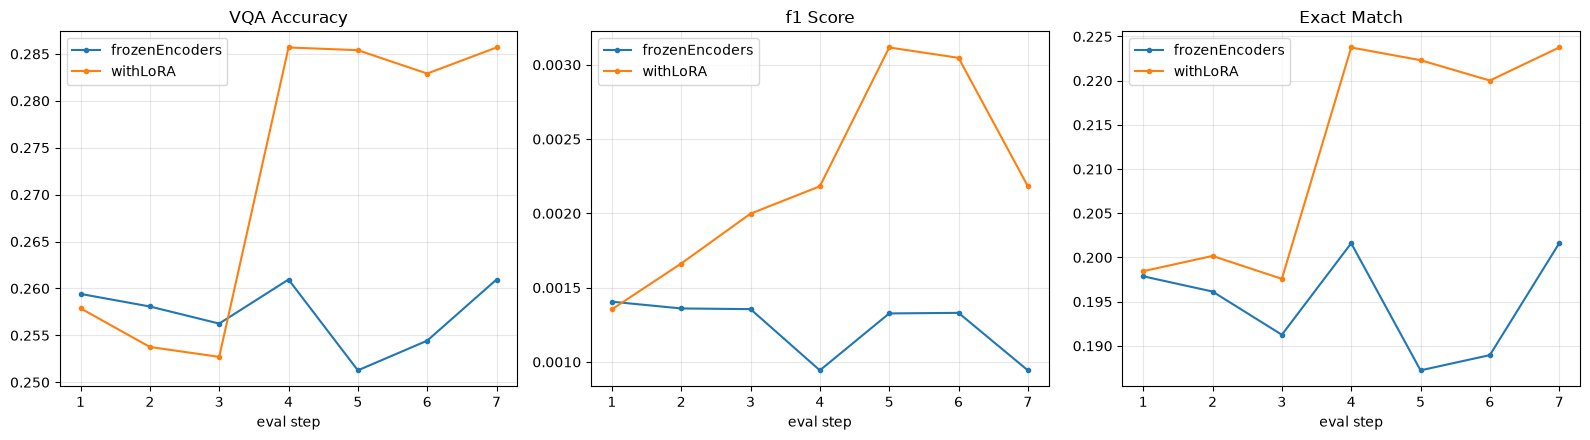

In [4]:
#----------------------------------------------------------------------------------------<Training curves overlay>-------||
figure, axis = plt.subplots(1, 3, figsize=(16, 4.5))

for key, name, ax in [("vqa", "VQA Accuracy", axis[0]),
                      ("f1", "f1 Score", axis[1]),
                      ("acc", "Exact Match", axis[2])]:
    for run, curve in curves.items():
        ax.plot(range(1, curve["steps"] + 1), curve[key], marker="o", markersize=3, label=run)
    ax.set_title(name)
    ax.set_xlabel("eval step")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(C.FIGURE_DIR / "runComparison.png", dpi=150, bbox_inches="tight")
plt.show()

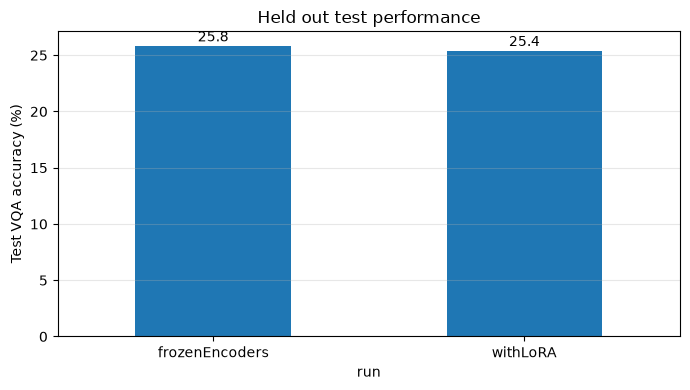

In [5]:
#----------------------------------------------------------------------------------------<Test VQA accuracy bars>--------||
if "testVQA" in table.columns:
    ax = (100 * table["testVQA"]).plot(kind="bar", figsize=(7, 4), rot=0)
    ax.set_ylabel("Test VQA accuracy (%)")
    ax.set_title("Held out test performance")
    ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(100 * table["testVQA"]):
        ax.text(i, v + 0.4, f"{v:.1f}", ha="center")
    plt.tight_layout()
    plt.savefig(C.FIGURE_DIR / "testAccuracy.png", dpi=150, bbox_inches="tight")
    plt.show()

In [6]:
#----------------------------------------------------------------------------------------<Markdown for the report>-------||
out = table.copy()
for col in ["valVQA", "testVQA", "testExact", "valF1"]:
    if col in out.columns:
        out[col] = (100 * out[col]).round(2)

text = out.to_markdown()
with open(ROOT / "report" / "results.md", "w") as file:
    file.write("# Results\n\n" + text + "\n")

print(text)

| run            |   trainLoss |   valVQA |   valF1 |   trainMins |   epochs |   testVQA |   testExact |
|:---------------|------------:|---------:|--------:|------------:|---------:|----------:|------------:|
| frozenEncoders |     4.42712 |    26.1  |    0.09 |        22.8 |        5 |     25.83 |       20.53 |
| withLoRA       |     3.92102 |    28.57 |    0.22 |        19   |        5 |     25.42 |       20.36 |
